In [3]:
import numpy as np
import scipy as sp
from scipy.fft import fft, fftfreq, ifft
import matplotlib.pyplot as plt
from tqdm import trange

rng = np.random.default_rng()

In [4]:
class BrunelModelA():
    def __init__(self, N, Next, g, J, Ce, D, vthr_ratio):
        self.N = int(N)
        self.Ne = int(0.8*N) # excitatory neurons
        self.Ni = int(0.2*N) # inhibitory neurons
        self.Next = Next # external input neurons
        
        self.Je = J # excitatory connection strength
        self.g = g
        self.Ji = - g * J # inhibitory connection strength
        
        self.Ce = Ce # nb of excitatory connections to a single neuron
        self.Ci = int(0.25 * Ce) # nb of inhibitory connections to a single neuron
        
        self.D = D # transmission delay of spikes
        self.refractory_period = 2e-3 # duration of the refractory period after spiking
        self.Vr = 10. # resting potential value in mV
        self.Vth = 20. # spiking threshold in mV
        self.te = 20e-3 # Time constant of excitatory neurons, from Brunel
        self.vthr = self.compute_vthr() # external firing rate threshold vthr = (Vth-Vr)/(Je*Ce*te)
        self.vext = vthr_ratio * self.vthr # external excitatory neurons firing rate 

        # Boolean for network-wide connectivity matrix initialization (used for inheritance)
        self.init_W()
        # Reset potentials and spikes
        self.reset()

    # Define the network-wide connectivity matrix W
    def init_W(self):
        self.W = np.zeros((self.N, self.N + self.Next))
        for i in range(self.N):
            Ne_idxs = rng.choice(self.Ne, self.Ce, replace=False)
            Ni_idxs = rng.choice(self.Ni, self.Ci, replace=False) + self.Ne
            Next_idxs = rng.choice(self.Next, self.Ce, replace=False) + self.N
            self.W[i, Ne_idxs] = self.Je
            self.W[i, Ni_idxs] = self.Ji
            self.W[i, Next_idxs] = self.Je
    
    def reset(self):
        self.V = np.full((1, self.N), self.Vr, dtype='float64') # all neurons are initiated at resting potential Vr
        self.spikes = np.zeros((1, self.N))
        self.spike_count = np.array(0)
        self.refractory_times = np.full(self.N, -1., dtype='float64') # array that holds the refractory periods as the elapsed time since last spike

    def compute_vthr(self):
        vthr = (self.Vth - self.Vr) / (self.Je * self.Ce * self.te)
        return vthr
    
    def compute_spike_count(self):
        self.spike_count = np.sum(self.spikes, axis = 1)
    
    def compute_step(self):
        # Internal spiking activity at time t - D
        delay = int(self.D//self.dt)
        if(delay + 1 > self.spikes.shape[0]):
            network_spikes = np.zeros(self.N)
        else:
            network_spikes = self.spikes[- 1 - delay]
        # External spiking excitation
        external_spikes = rng.poisson(self.vext, self.Next)
        #external_spikes = np.random.choice([0, 1], p=[1 - self.dt*self.vext, self.dt*self.vext], size = self.Next)
        # Total input
        spikes = np.concatenate([network_spikes, external_spikes])
        # Potential update (see Brunel, eq. 1)
        new_V = self.V[-1] + self.dt * (- (self.V[-1] - self.Vr) / self.te + np.matvec(self.W, spikes))
        # Neurons in refractory period remain unchanged
        new_V[self.refractory_times >= 0] = self.Vr # Reset to resting potential
        self.refractory_times[self.refractory_times >= 0] += self.dt # Update the time since last spike
        self.refractory_times[self.refractory_times > self.refractory_period] = -1 # Ready to spike
        # Compute the spikes
        new_spikes = np.where(new_V > self.Vth, 1, 0)
        # Update the new refractory neurons
        self.refractory_times[new_spikes == 1] = 0 # Start refractory period
        self.V = np.concatenate([self.V, [new_V]])
        self.spikes = np.concatenate([self.spikes, [new_spikes]])

    def compute_activity(self, T, dt):
        self.reset()
        n_steps = int(T//dt)
        self.T = T
        self.dt = dt
        self.n_steps = n_steps
        for i in trange(n_steps, desc="Computing potential dynamics step"):
            self.compute_step()
        self.compute_spike_count()

    def plot_raster(self):
        event = []
        for i in range(self.N):
            st = self.spikes[:, i]
            event.append(np.nonzero(st)[0])
        plt.eventplot(event, colors='k', zorder = 0)

In [300]:
model = BrunelModelA(N=12500, Next=10000, g=5, J=0.2, Ce=800, D=2e-3, vthr_ratio=0.9999)

In [301]:
model.compute_activity(2, 1e-3)

Computing potential dynamics step: 100%|███████████████████████████████████████████| 1999/1999 [04:15<00:00,  7.82it/s]


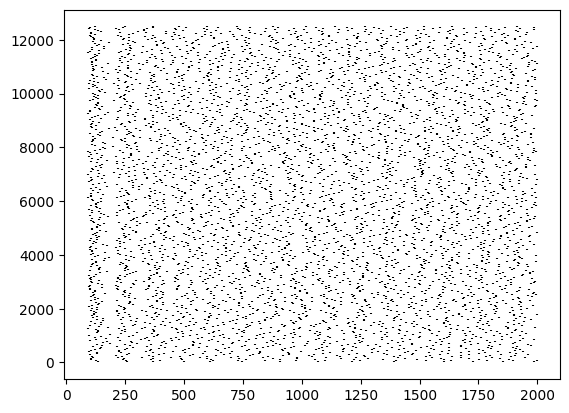

In [302]:
model.plot_raster()

In [ ]:
class BrunelModelA_bis():
    def __init__(self, N, Next, g, J, Ce, D, vext):
        self.N = N
        self.N1 = int(0.8*N) # excitatory neurons
        self.N2 = int(0.2*N) # inhibitory neurons
        self.Next = Next # external input neurons
        
        self.Je = J # excitatory connection strength
        self.g = g
        self.Ji = - g * J # inhibitory connection strength
        
        self.Ce = Ce # nb of excitatory connections to a single neuron
        self.Ci = 0.25 * Ce # nb of inhibitory connections to a single neuron
        
        self.D = D # transmission delay of spikes
        self.vext = vext # external excitatory neurons firing rate
        self.refractory_period = 2e-3 # duration of the refractory period after spiking
        self.Vr = 10 # resting potential value in mV
        self.Vth = 20 # spiking threshold in mV
        self.te = 20e-3 # Time constant of excitatory neurons, from Brunel
        
        # Define the network-wide connectivity matrix W
        self.W = np.empty((self.N, self.N + self.Next))
        for i in range(self.N):
            self.W[i] = np.concatenate([np.random.choice([0, self.Je], p=[1-self.Ce/self.N1, self.Ce/self.N1], size = self.N1),
                                        np.random.choice([0, self.Ji], p=[1-self.Ci/self.N2, self.Ci/self.N2], size = self.N2),
                                        np.random.choice([0, self.Je], p=[1-self.Ce/self.N1, self.Ce/self.N1], size = self.Next)])
        # Reset potentials and spikes
        self.reset()
    
    def reset(self):
        self.V = np.full((1, self.N), self.Vr, dtype='float64') # all neurons are initiated at resting potential Vr
        self.spikes = np.zeros((1, self.N))
        self.spike_count = np.array(0)
        self.refractory_times = np.full(self.N, -1., dtype='float64') # array that holds the refractory periods as the elapsed time since last spike

    def compute_spike_count(self):
        self.spike_count = np.sum(self.spikes, axis = 1)
    
    def compute_step(self):
        # Internal spiking activity at time t - D
        delay = int(self.D//self.dt)
        if(delay + 1 > self.spikes.shape[0]):
            network_spikes = np.zeros(self.N)
        else:
            network_spikes = self.spikes[- 1 - delay]
        # External spiking excitation
        external_spikes = np.random.choice([0, 1], p=[1 - self.dt*self.vext, self.dt*self.vext], size = self.Next)
        # Total input
        spikes = np.concatenate([network_spikes, external_spikes])
        # Potential update (see Brunel, eq. 1)
        new_V = self.V[-1] + self.dt * (- (self.V[-1] - self.Vr) / self.te + np.matvec(self.W, spikes))
        # Neurons in refractory period remain unchanged
        new_V[self.refractory_times >= 0] = self.Vr # Reset to resting potential
        self.refractory_times[self.refractory_times >= 0] += self.dt # Update the time since last spike
        self.refractory_times[self.refractory_times > self.refractory_period] = -1 # Ready to spike
        # Compute the spikes
        new_spikes = np.where(new_V > self.Vth, 1, 0)
        # Update the new refractory neurons
        self.refractory_times[new_spikes == 1] = 0 # Start refractory period
        self.V = np.concatenate([self.V, [new_V]])
        self.spikes = np.concatenate([self.spikes, [new_spikes]])

    def compute_activity(self, T, dt):
        self.reset()
        n_steps = int(T//dt)
        self.T = T
        self.dt = dt
        self.n_steps = n_steps
        for i in trange(n_steps, desc="Computing potential dynamics step"):
            self.compute_step()
        self.compute_spike_count()

    def plot_raster(self):
        event = []
        for i in range(self.N):
            st = self.spikes[:, i]
            event.append(np.nonzero(st)[0])
        plt.eventplot(event, colors='k', zorder = 0)

    def plot_W(self):
        plt.imshow(self.W)

In [292]:
# Example of slow, synchronous oscillations.
model = BrunelModelA_bis(N = 1250, Next = 1000, g=0.4, J=4, Ce=400, D=2e-3, vext=300)
model.compute_activity(1, 1e-3)
model.plot_raster()
plt.xlabel("Time in ms")
plt.title(rf"Brunel modelA_bis Raster ($N={model.N}, N_{'ext'} = {model.Next}, g={model.g}, J={model.Je}, C_e={model.Ce}, D={model.D}, \nu_{'ext'}={model.vext}Hz$)")
#plt.savefig("Brunel model A bis synchronous slow oscillations raster")
plt.show()

plt.plot(model.spike_count[:600])
plt.xlabel("Time in ms")
plt.ylabel("Network-wide spike count")
plt.title(fr"Brunel modelA_bis Spike count ($N={model.N}, N_{'ext'} = {model.Next}, g={model.g}, J={model.Je}, C_e={model.Ce}, D={model.D}, \nu_{'ext'}={model.vext}Hz$)")
#plt.savefig("Brunel model A bis synchronous slow oscillations spike count")
plt.show()

NameError: name 'BrunelModelA_bis' is not defined

Computing potential dynamics step: 100%|████████████████████████████████████████████| 999/999 [00:02<00:00, 364.54it/s]


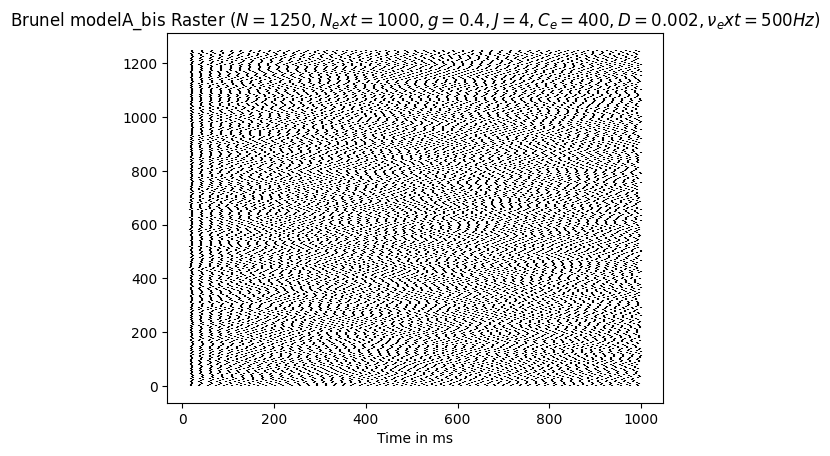

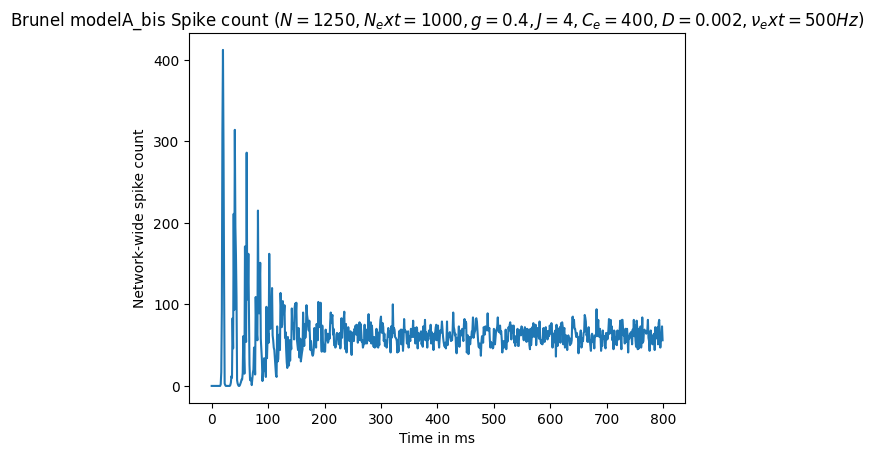

In [113]:
# Example of decaying synchronicity then small, fast oscillations
model = BrunelModelA_bis(N = 1250, Next = 1000, g=0.4, J=4, Ce=400, D=2e-3, vext=500)
model.compute_activity(1, 1e-3)
model.plot_raster()
plt.xlabel("Time in ms")
plt.title(rf"Brunel modelA_bis Raster ($N={model.N}, N_{'ext'} = {model.Next}, g={model.g}, J={model.Je}, C_e={model.Ce}, D={model.D}, \nu_{'ext'}={model.vext}Hz$)")
#plt.savefig("Brunel model A bis asynchrony raster")
plt.show()

plt.plot(range(0,600), model.spike_count[:600])
plt.xlabel("Time in ms")
plt.ylabel("Network-wide spike count")
plt.title(fr"Brunel modelA_bis Spike count ($N={model.N}, N_{'ext'} = {model.Next}, g={model.g}, J={model.Je}, C_e={model.Ce}, D={model.D}, \nu_{'ext'}={model.vext}Hz$)")
#plt.savefig("Brunel model A bis asynchrony spike count")
plt.show()

Computing potential dynamics step: 100%|████████████████████████████████████████████| 999/999 [00:02<00:00, 383.15it/s]


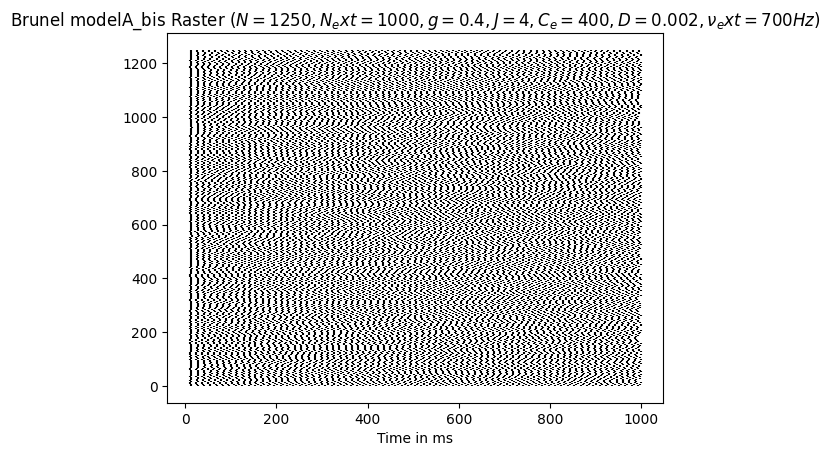

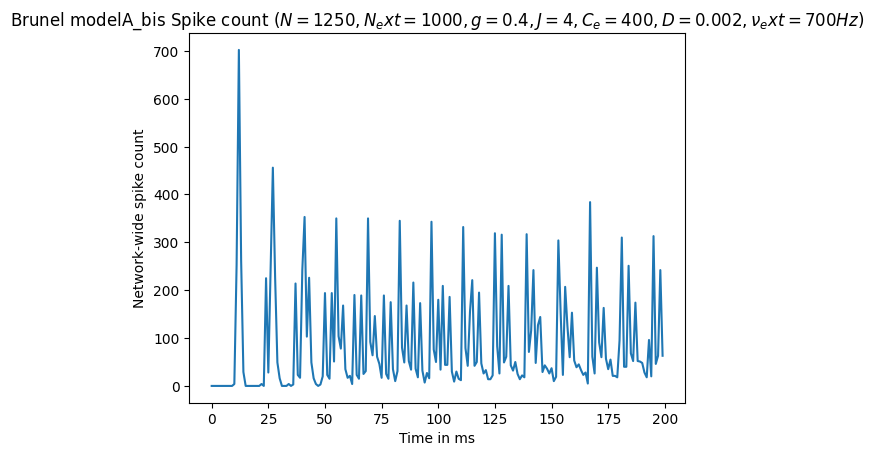

In [110]:
# Example of fast oscillations
model = BrunelModelA_bis(N = 1250, Next = 1000, g=0.4, J=4, Ce=400, D=2e-3, vext=700)
model.compute_activity(1, 1e-3)
model.plot_raster()
plt.xlabel("Time in ms")
plt.title(rf"Brunel modelA_bis Raster ($N={model.N}, N_{'ext'} = {model.Next}, g={model.g}, J={model.Je}, C_e={model.Ce}, D={model.D}, \nu_{'ext'}={model.vext}Hz$)")
plt.savefig("Brunel model A bis synchronous fast oscillations raster")
plt.show()

plt.plot(range(0,200), model.spike_count[:200])
plt.xlabel("Time in ms")
plt.ylabel("Network-wide spike count")
plt.title(fr"Brunel modelA_bis Spike count ($N={model.N}, N_{'ext'} = {model.Next}, g={model.g}, J={model.Je}, C_e={model.Ce}, D={model.D}, \nu_{'ext'}={model.vext}Hz$)")
plt.savefig("Brunel model A bis synchronous fast oscillations spike count")
plt.show()

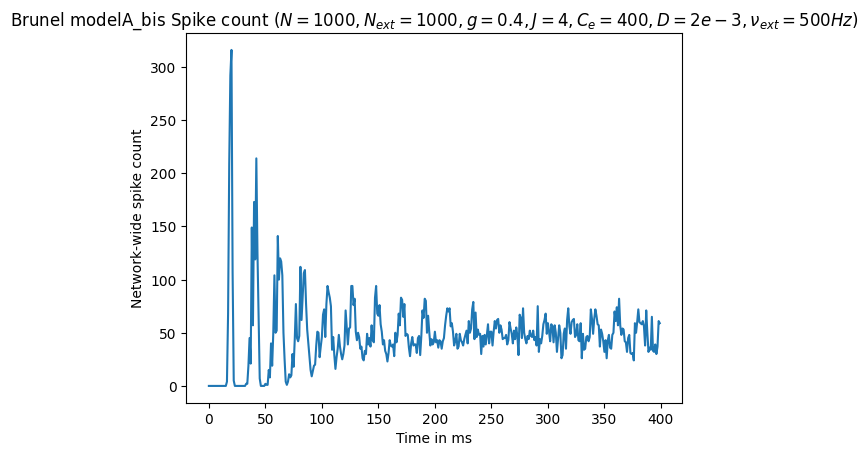

In [94]:
plt.plot(model_bis.spike_count[:400])
plt.xlabel("Time in ms")
plt.ylabel("Network-wide spike count")
plt.title(r"Brunel modelA_bis Spike count ($N=1000, N_{ext} = 1000, g=0.4, J=4, C_e=400, D=2e-3, \nu_{ext}=500Hz$)")
plt.savefig("Brunel model A bis decreasing oscillations spike count")

In [48]:
class ConnectedClusters(BrunelModelA):
    def __init__(self, N1, N2, Next, g, J, Ce, D, vthr_ratio):
        self.N1 = N1
        self.N2 = N2
        Ni = int(0.25*(N1+N2))
        super().__init__(N1+N2+Ni, Next, g, J, Ce, D, vthr_ratio)

    # Define the network-wide connectivity matrix W
    def init_W(self):
        self.W = np.zeros((self.N, self.N + self.Next))
        # Cluster 1
        for i in range(self.N1):
            N1_idxs = rng.choice(self.N1, self.Ce, replace=False)
            Ni_idxs = rng.choice(self.Ni, self.Ci, replace=False) + self.Ne
            Next_idxs = rng.choice(self.Next, self.Ce, replace=False) + self.N
            self.W[i, N1_idxs] = self.Je # intern to cluster 1
            self.W[i, Ni_idxs] = self.Ji # basket cells
            self.W[i, Next_idxs] = self.Je # external input
        # Cluster 2
        for i in range(self.N2):
            N2_idxs = rng.choice(self.N2, self.Ce, replace=False) + self.N1
            Ni_idxs = rng.choice(self.Ni, self.Ci, replace=False) + self.Ne
            Next_idxs = rng.choice(self.Next, self.Ce, replace=False) + self.N
            self.W[i + self.N1, N2_idxs] = self.Je # intern to cluster 2
            self.W[i + self.N1, Ni_idxs] = self.Ji # basket cells
            self.W[i + self.N1, Next_idxs] = self.Je # external input
        # Basket cells
        for i in range(self.Ni):
            #ratio = np.random.rand()
            #n = int(ratio*self.Ce)
            N1_idxs = rng.choice(self.N1, self.Ce, replace=False)
            N2_idxs = rng.choice(self.N2, self.Ce, replace=False) + self.N1
            self.W[i + self.Ne, N1_idxs] = self.Je # from cluster 1
            self.W[i + self.Ne, N2_idxs] = self.Je # from cluster 2

    def plot_raster(self):
        event = []
        for i in range(self.N):
            st = self.spikes[:, i]
            event.append(np.nonzero(st)[0])
        colors = np.concatenate([np.full(self.N1, 'b'), np.full(self.N2, 'k'), np.full(self.Ni, 'r')])
        plt.eventplot(event, colors=colors, zorder = 0)

Computing potential dynamics step: 100%|███████████████████████████████████████████| 999/999 [00:00<00:00, 1494.35it/s]


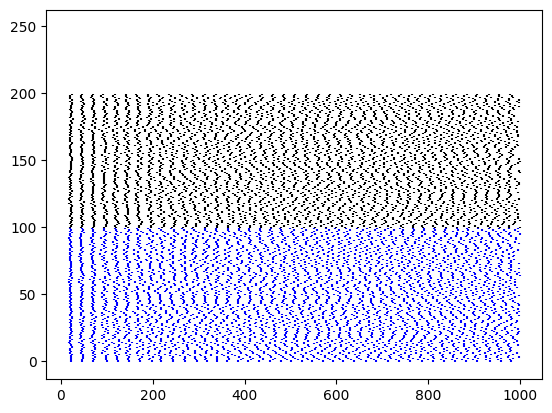

In [49]:
model2 = ConnectedClusters(N1=100, N2=100, Next=100, g=5, J=50, Ce=10, D=2e-3, vthr_ratio=1.5)
model2.compute_activity(1, 1e-3)
model2.plot_raster()

In [52]:
model2.plot_W()

AttributeError: 'ConnectedClusters' object has no attribute 'plot_W'

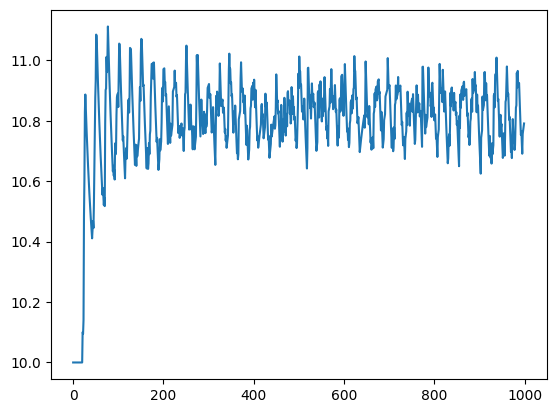

In [51]:
plt.plot(model2.V[:, 200])